# SWAG-P Simulation with Gap Plasmon Explorer

#### GP Explorer is a handly tools allowing to manipulate GP geometries and visualize its reflectance under differents configurations. Then, how maximum absorption shift depending on refractive index changes can be study without knowledge about coding as well as without studing gap plasmon phenomenon.
Yet, just for enjoy physics, it must be known that a GP, that is a solution of Maxwell's equations without source -a guided electromagnetic wave into dielectric-, must be undertand as a mode of the nano cavity -the so called "gap"- between two close metallic regions.


After set up the environment by importing necessary modules and defining paths to required data files ensuring that all dependencies are correctly loaded and accessible for subsequent computations, it's time to choose the design of your system ! Thanks to the dynamical plan of your gap plasmon geometries, you can select relevant values while observe how the configurations evolves. For better taking in hands, you can begin by load classicals préconfigurations, appreciate the structure from dynamical drawing and then pass to the next widget, the material selector. But if you prefer to design your own structure, and to facilitate manipulations, you have juste to select your values, choose a relevant and meaningful configuration name, and Add your configuration with the button made for. After all of your configurations added, you must Save and Quit.

It should be noted that you can obviously load or delete any configurations already saved, modify them as you think best, and select update button. Don't forget to Save and Quit before going to the next part !

Since on account of the scale ratio between the differents layers, keep the real dimension didn't allows for good visualization of each materials. The presence of hatch in both super and substrate are justified by the thickness of these layers and depict those sections which are not drawn. 

It is relevant to distinguish two cases where significant deviations appear between the reflectance spectra of two distinct geometries. In the first case, "Case A = Structure 1", the lateral sides of the nanocube — our resonator — are entirely in contact with the surrounding medium, defined here as the superstrate. In the second case, "Case B = Structure 2", the combined width of the Dielectric, Functionalization, and Molecule layers exceeds the nanocube width. This geometric distinction must be accurately implemented in the code to better approximate the actual structure of a real Gap Plasmon Sensor.

In [1]:
### INITIALIZATION SCRIPT
# This script is executed at the beginning to set up the environment.
# It ensures that the notebook is trusted, detects the project root, and adds necessary directories to the PYTHONPATH.
# It also defines shared paths for the workspace, notebooks, summary, experimental data, and combined materials JSON file.

import sys, subprocess
from pathlib import Path


# 1) Trust this notebook (silencieusement si ça échoue)
nb = Path().resolve()
try:
    subprocess.run(
        [sys.executable, "-m", "jupyter", "trust", str(nb)],
        check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )
except Exception:
    pass  # no worries if trust fails

# 2) Détecter racine du projet (parent contenant "modules" et "data")
cwd = Path().resolve()
project_root = cwd
for p in [cwd] + list(cwd.parents):
    if (p / "modules").is_dir() and (p / "data").is_dir():
        project_root = p
        
        break

# 3) Ajouter au PYTHONPATH les dossiers utiles s’ils existent
for folder in ("modules", "tools", "notebooks"):
    d = project_root / folder
    if d.is_dir():
        sys.path.insert(0, str(d))

# 4) Définir les chemins partagés
workspace_dir      = project_root
notebooks_dir      = project_root / "notebooks"
summary_dir        = notebooks_dir / "Summary_Simulation"
exp_data_dir       = notebooks_dir / "Experimental_Data"
data_dir           = project_root / "data"
json_combined_path = data_dir / "combined_materials.json"

In [ ]:
# %% Cellule 2 – Geometry settings
from geometry_settings import create_geometry_widget

# Issues with values input directly in the widget
# Affichage du widget de configuration de la géométrie
geometry_widget = create_geometry_widget()
display(geometry_widget)

Here you can chose which materials -by actually select its permitivitiy- will be implement in each layers previously saved to make the Gap Plasmon geometry. To acheive this, you just have to start selection again but this time without sliders but with different modes. 

1) Firstly, you can simply choose "None" to depict the absence of the materials. Becarefull, "None" apply a permitivity equal to one. Then, choose "None" is most for your general understanding than for real computation. The important point here is to apply a thickness equal to zero for such a lack of materials. 

2) Anyway, you can obviously select your own values with the "Custom" mode. Don't forget to apply the square of your value if you have the refractive index ! In a non magnetic materials (i.e.  $\mu_r = 1 $), complexe refractive index $ \tilde{n} $ is link to the complex permitivity $ \tilde{\varepsilon} $ via :
$$
\tilde{n}^2 = \tilde{\varepsilon}
$$
Equation which link the material EM response $ \tilde{\varepsilon} $ and its behavior in front of the light propagation $ \tilde{n} $.

3) More over, from a short list of common materials, you can quickly select them from the "Standard" mode to configure your Gap Plasmon design.

4) Finally, thanks to the Refractiveindex.INFO Database, you can with the "RefractiveIndex" mode, load every materials you need ! By firstly choosing the appropriate "Shelf", you can selecte from "Book" your materials and then "Page" offers the possibility to choose from which searches values are computed.


In [4]:
from material_selector import MaterialSelectorTabbedNotebook, DEFAULT_ROLES

# Instanciation et affichage du sélecteur dans le Notebook
selector = MaterialSelectorTabbedNotebook(DEFAULT_ROLES)
selector.display()

As previously said, you can following the same way to add, delete and/or load material configurations, update modifications, and Save and Quit ! But you have also at the begining two préconfigurations already saved, depicting the two commons structures S1 and S2. You can also delete them, add a new one or update materials as you wish. 

After having Save and Quit, you can from now one Combine your different configurations!
That means that each geometries configurations can be combine with each materials configurations to design and come out your Gap Plasmon structure.


In [ ]:
from Geometry_Material_Config import create_geometry_material_widget
w = create_geometry_material_widget()
display(w)

## After having linked geometries and materials to finally design differents system's configuration, the only thing left to do is to plott your work !

The following widget is separate into three tab. 

#### I – The first section allows you to simulate and plot the reflectance spectra of different system configurations.

You can specify the wavelength range over which the simulations will be performed, as well as the number of points used in that range. This determines the spectral resolution of your simulation.

In addition, and this part is slightly more advanced, you can define the number of Fourier harmonics (also called “modes”) used in the Rigorous Coupled-Wave Analysis (RCWA) algorithm. This number directly impacts the accuracy and computational cost of the simulation. RCWA works by decomposing the electromagnetic fields and the permittivity profile of the structure into a Fourier series, and then solving Maxwell’s equations in this modal space. The more modes you include, the better the approximation — but the simulation will also take more time and memory.

In our case, we chose to use 70 modes. This value was determined by performing a convergence study at a fixed wavelength of 700 nm. Specifically, we calculated the reflectance for increasing numbers of modes and observed that the result became stable (i.e., the changes in reflectance became negligible) beyond 70 modes. This indicates that the system has converged numerically for this wavelength, and that 70 modes is a good compromise between precision and performance. If the reflectance diverges beyond a certain number of modes (e.g., 100), it is usually due to numerical instabilities in the RCWA algorithm. This can result from poorly conditioned matrices, accumulation of round-off errors, or limitations in the Fourier representation of sharp index profiles. In such cases, increasing the number of modes no longer improves accuracy and may instead degrade the results.

You have the possibility to download all figures ploted and all texte files correspondinf to the summary of each simulation ever made. 

#### II -The second tab is about the plotting of all your spectra in one figure, with a summary of each spectra bellow. 

#### III -The third tab allows cheking to ensure the validity of our results. 
You can plot de difference between two reflectances simulations made with two different approaches which should be similar but which could also present some deviation. Observing fluctuation close to $10^-14$ attest to a statistical behavior and ensure the validity of our result.

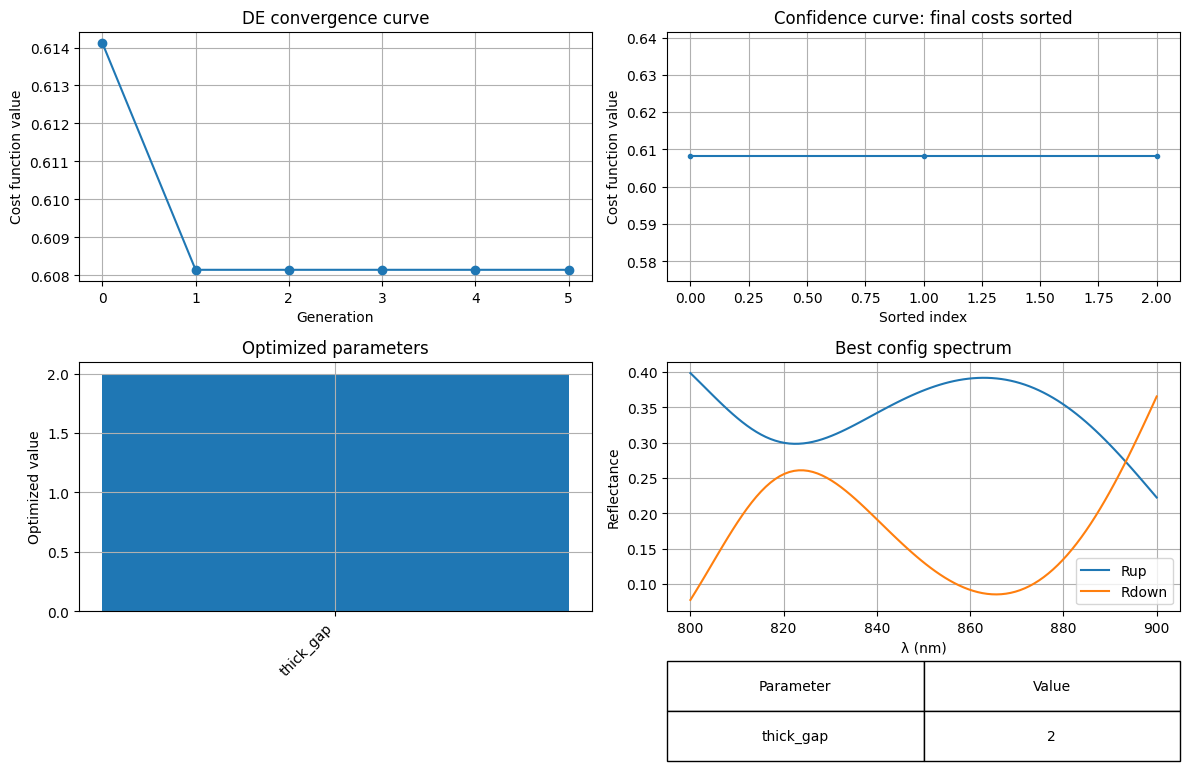

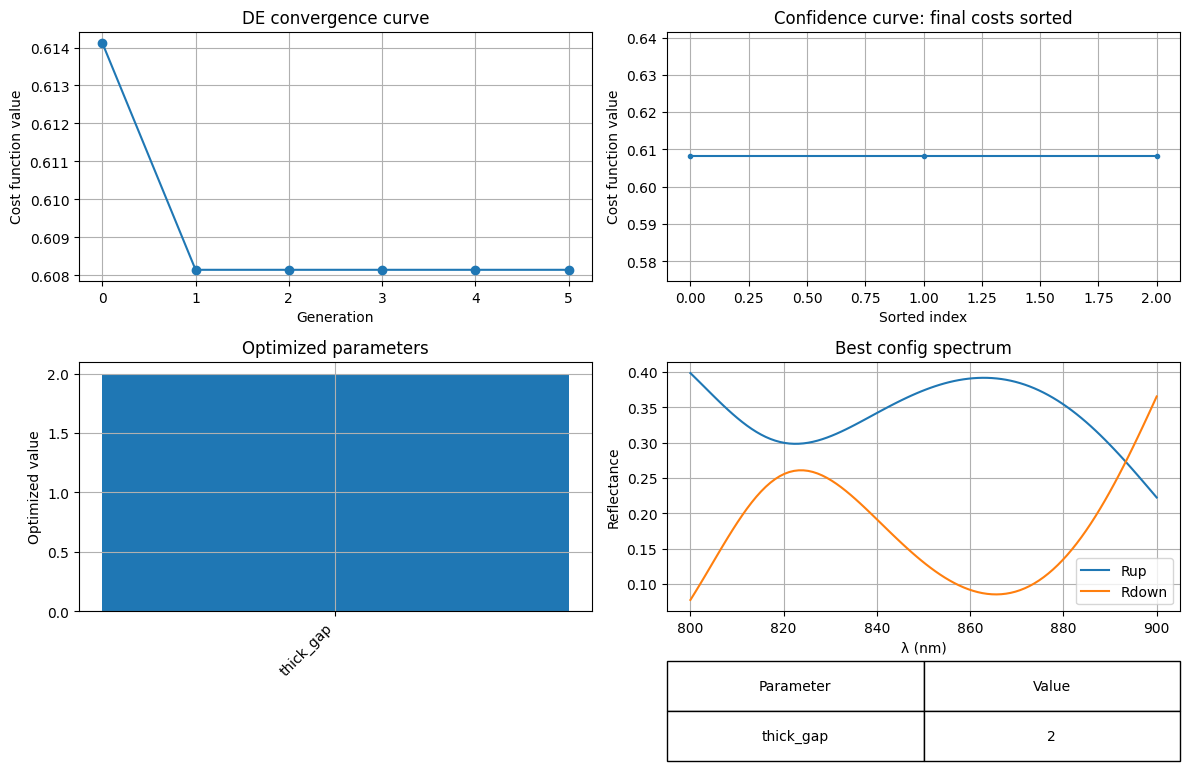

In [2]:
from interactive_simulation import create_advanced_app
from IPython.display import display

# Crée et affiche l'interface complète
app = create_advanced_app()
display(app)